In [4]:
import pandas as pd
import sqlite3
import numpy as np
import warnings
warnings.filterwarnings('ignore')
    
# 1. Load CSV into a DataFrame
df1 = pd.read_csv("occupazione.csv")
df2 = pd.read_csv("disoccupazione.csv")
    
# 2. Connect to SQLite database (creates file if it doesn't exist)
conn = sqlite3.connect("sample_database.db")
    
# 3. Write DataFrame to a SQLite table
df1.to_sql("occupation_zone", conn, if_exists="replace", index=False)
df2.to_sql("disoccupation_zone", conn, if_exists="replace", index=False)
    
# 4. Close connection
#conn.close()
print("Data successfully loaded into SQLite database")

#df1.head()
df2.head()

Data successfully loaded into SQLite database


,iso_code,country,sex,age,year,obs_value
0,AFG,Afghanistan,Total,15+,2025,13.351
1,AFG,Afghanistan,Total,15-24,2025,16.785
2,AFG,Afghanistan,Total,25+,2025,11.340
3,AFG,Afghanistan,Male,15+,2025,12.503
4,AFG,Afghanistan,Male,15-24,2025,15.814


In [5]:
df1 = pd.read_sql_query("SELECT * FROM occupation_zone", conn)
print(df1)
#df2 = pd.read_sql_query("SELECT * FROM disoccupation_zone", conn)

      iso_code      country     sex    age  year  obs_value
0          AFG  Afghanistan   Total    15+  2025     32.457
1          AFG  Afghanistan   Total  15-24  2025     31.419
2          AFG  Afghanistan   Total    25+  2025     33.056
3          AFG  Afghanistan    Male    15+  2025     61.038
4          AFG  Afghanistan    Male  15-24  2025     57.355
...        ...          ...     ...    ...   ...        ...
57514      ZWE     Zimbabwe    Male  15-24  1991     56.380
57515      ZWE     Zimbabwe    Male    25+  1991     79.360
57516      ZWE     Zimbabwe  Female    15+  1991     57.601
57517      ZWE     Zimbabwe  Female  15-24  1991     45.019
57518      ZWE     Zimbabwe  Female    25+  1991     65.530

[57519 rows x 6 columns]


In [15]:
df1.info()
print("shape of dataframe" , df1.shape)
print("shape of dataframe" , df1.columns.tolist())
print("shape of dataframe" , df2.shape)
print("shape of dataframe" , df2.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57519 entries, 0 to 57518
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   iso_code   57519 non-null  object 
 1   country    57519 non-null  object 
 2   sex        57519 non-null  object 
 3   age        57519 non-null  object 
 4   year       57519 non-null  int64  
 5   obs_value  57519 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 2.6+ MB
shape of dataframe (57519, 6)
shape of dataframe ['iso_code', 'country', 'sex', 'age', 'year', 'obs_value']
shape of dataframe (57519, 6)
shape of dataframe ['iso_code', 'country', 'sex', 'age', 'year', 'obs_value']


In [6]:
import pandas as pd
info_df = pd.DataFrame({})

# Now you can drop the column
#info_df = info_df.drop(columns=['CheckMissingValues'])

In [7]:
info_df['dtypes']    = df1.dtypes 
info_df['missingvalues']    =   df1.isnull().any()
info_df['uniquevalues']    =  df1.nunique()
info_df['min']    = df1.select_dtypes(include='number').min()
info_df['max']    = df1.select_dtypes(include='number').max()
info_df['mean']   = df1.select_dtypes(include='number').mean()
info_df['std']    = df1.select_dtypes(include='number').std()
info_df['median'] = df1.select_dtypes(include='number').median()
                       

In [8]:
info_df

,dtypes,missingvalues,uniquevalues,min,max,mean,std,median
iso_code,object,False,183,NaN,NaN,NaN,NaN,NaN
country,object,False,183,NaN,NaN,NaN,NaN,NaN
sex,object,False,3,NaN,NaN,NaN,NaN,NaN
age,object,False,3,NaN,NaN,NaN,NaN,NaN
year,int64,False,35,1991.000,2025.000,2007.964951,10.082723,2008.00
obs_value,float64,False,39986,1.741,98.535,52.646644,19.731751,54.16


In [9]:
print(f'\nYear range  : {df1["year"].min()} to {df1["year"].max()}')
print(f'Countries   : {df1["country"].nunique()}')
print(f'Sex values  : {df1["sex"].unique().tolist()}')
print(f'Age groups  : {df1["age"].unique().tolist()}')
print(f'\nobs_value stats:\n{df1["obs_value"].describe().round(3).to_string()}')


Year range  : 1991 to 2025
Countries   : 183
Sex values  : ['Total', 'Male', 'Female']
Age groups  : ['15+', '15-24', '25+']

obs_value stats:
count    57519.000
mean        52.647
std         19.732
min          1.741
25%         38.745
50%         54.160
75%         67.203
max         98.535


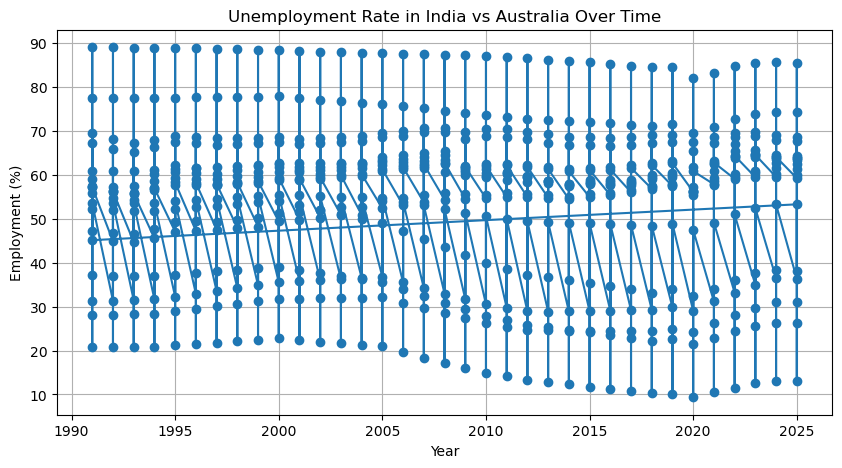

In [27]:
import matplotlib.pyplot as plt

df_country = df1[df1['country'].isin(['India', 'Australia'])]

plt.figure(figsize=(10,5))
plt.plot(df_country['year'], df_country['obs_value'], marker='o')

plt.title(f"Unemployment Rate in India vs Australia Over Time")
plt.xlabel("Year")
plt.ylabel("Employment (%)")
plt.grid(True)
plt.show()

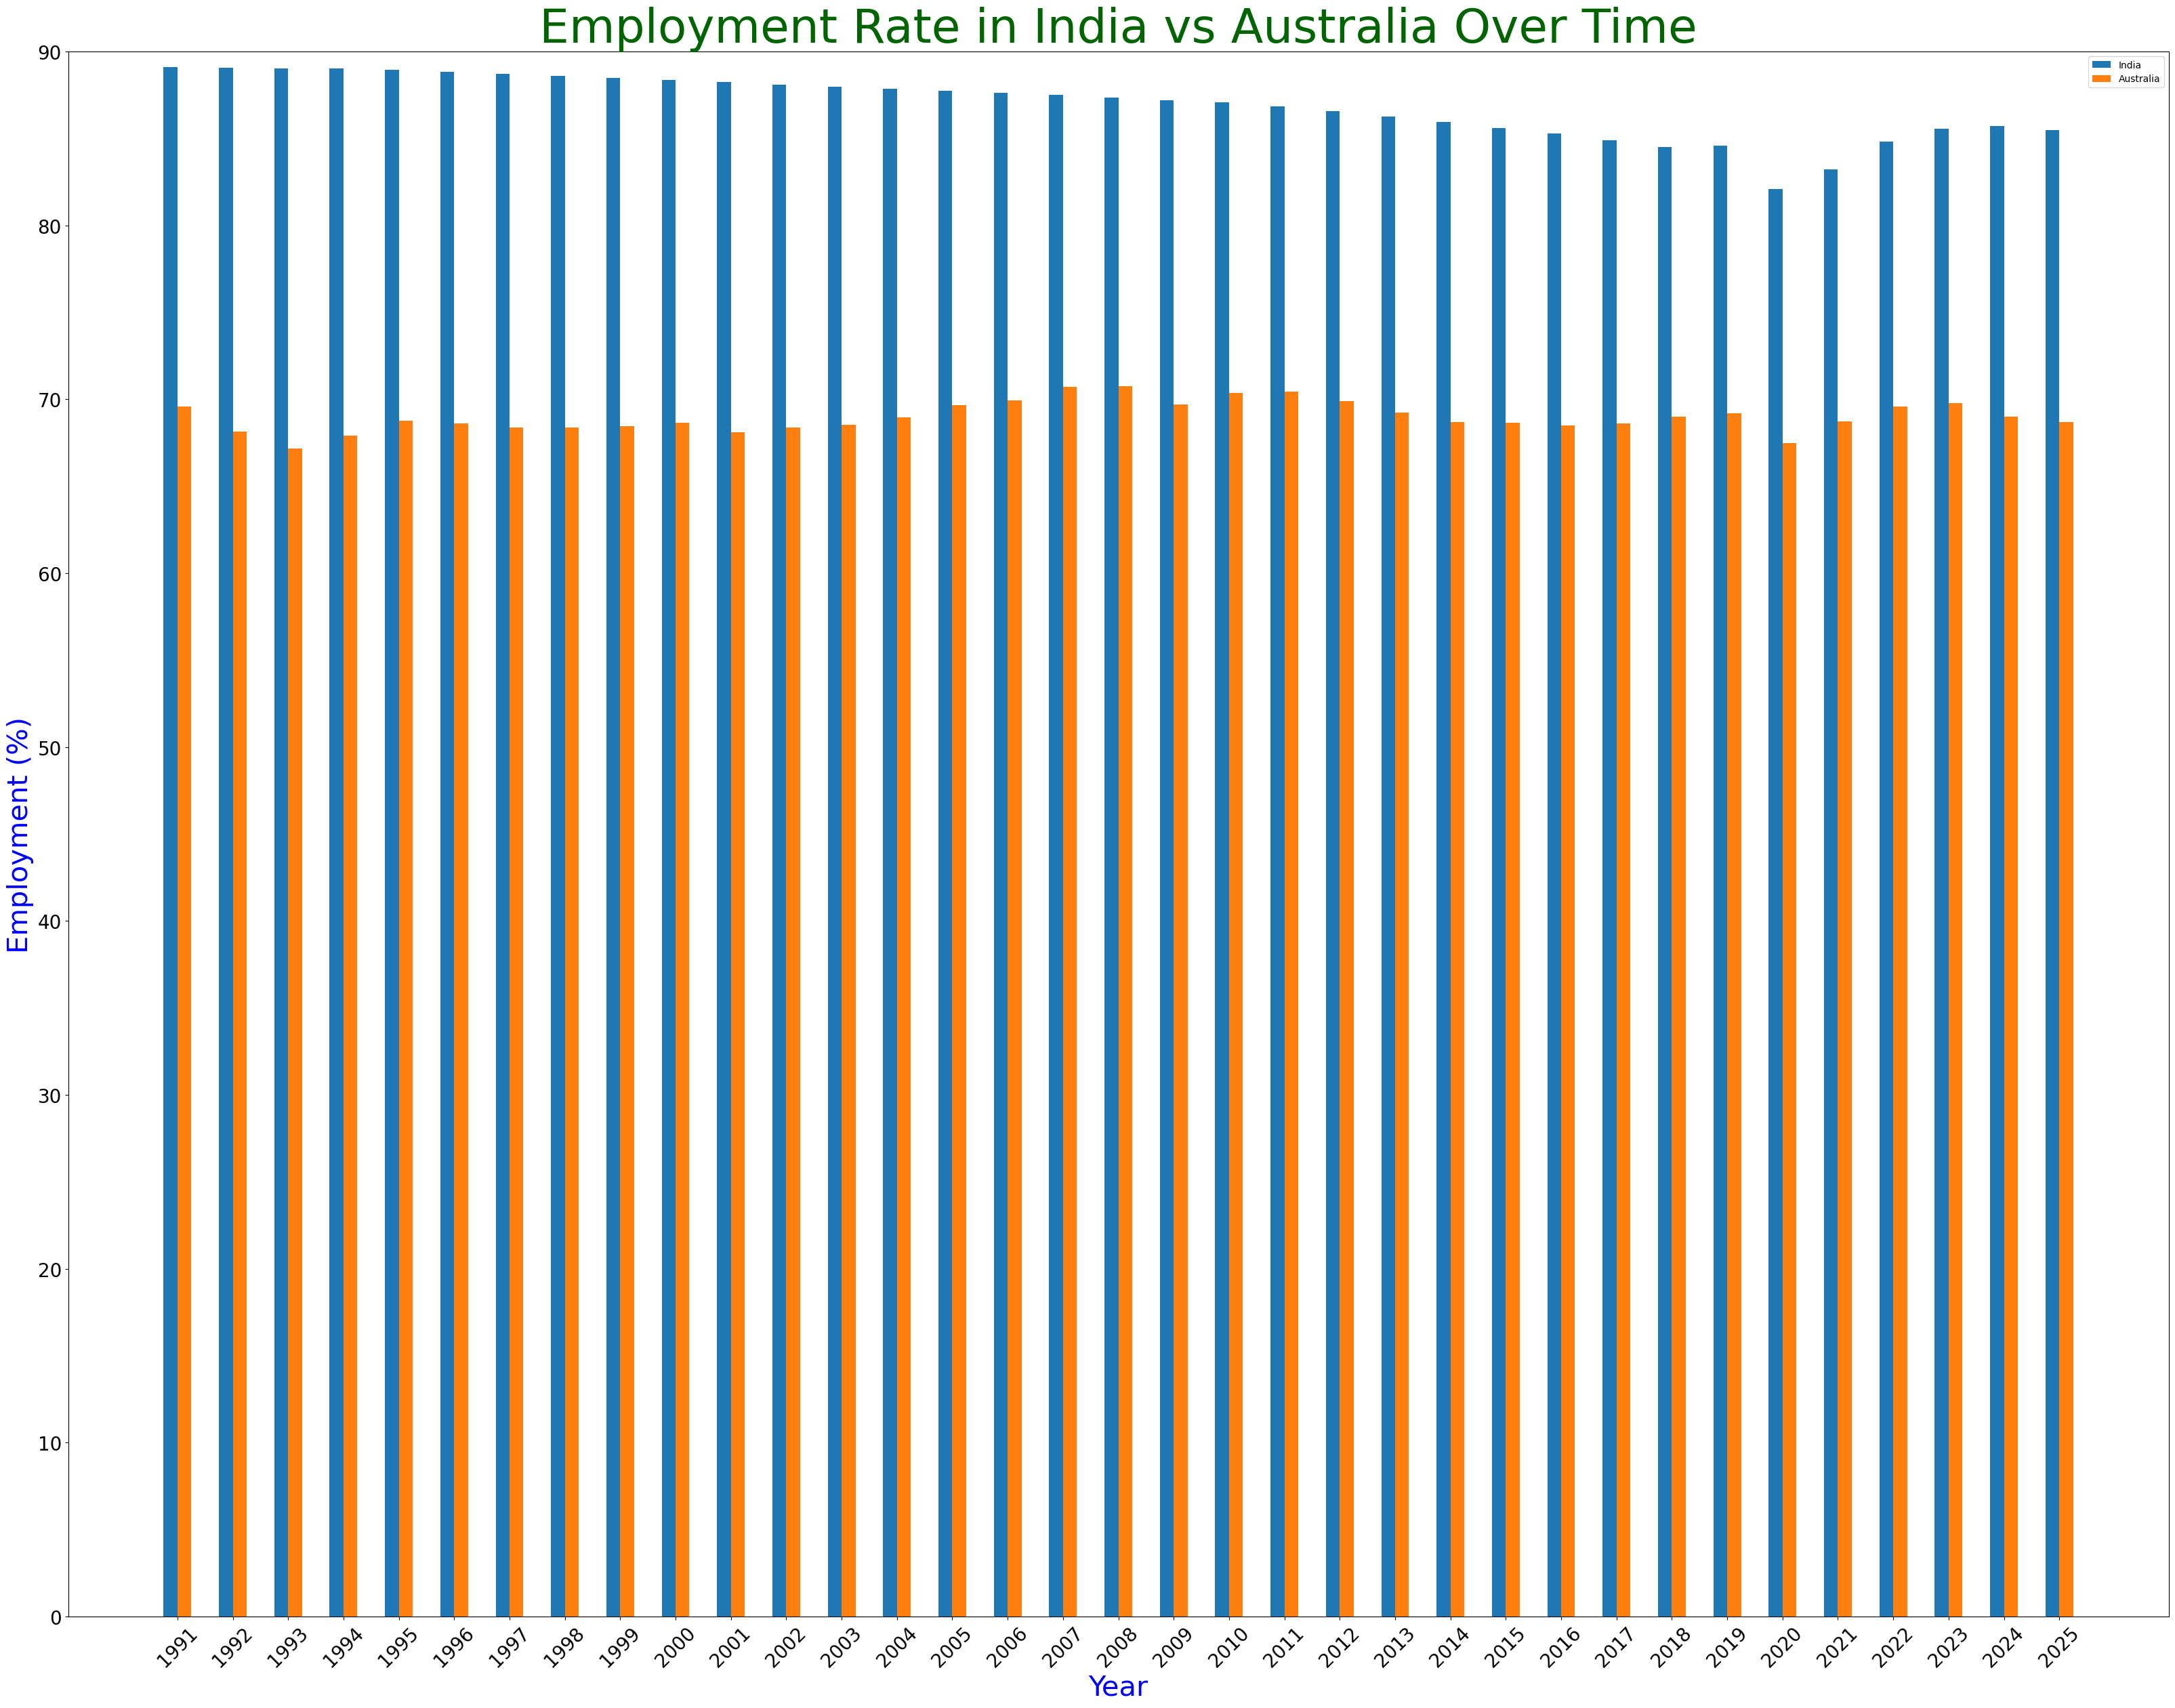

In [26]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(40, 30))

# Filter data Take max obs_value per year for each country
country1_df = df1[df1['country'] == 'India'].groupby('year')['obs_value'].max()
country2_df = df1[df1['country'] == 'Australia'].groupby('year')['obs_value'].max()
country1_df
# Extract unique years (sorted) values for each yea
years = sorted(df1['year'].unique())
country1 = [country1_df.get(y, np.nan) for y in years]
country2 = [country2_df.get(y, np.nan) for y in years]

# X positions
x = np.arange(len(years))
width = 0.25

# Plot
plt.bar(x - width/2, country1, width, label="India")
plt.bar(x + width/2, country2, width, label="Australia")

# Labels and title
plt.xticks(x, years, fontsize = 20 ,rotation=45)
plt.ylim(0, 90)
plt.yticks(fontsize = 20)
plt.xlabel("Year", fontsize = 30,color="blue")
plt.ylabel("Employment (%)",fontsize = 30,color="blue")
plt.title("Employment Rate in India vs Australia Over Time",fontsize = 50,color="darkgreen")
plt.legend()

plt.show()


In [24]:
#Testvalues for 1 year occupation_zone 
df1_test = pd.read_sql_query("SELECT * FROM occupation_zone where country in ('India','Australia') and year = '2025'", conn)
print(df1_test)

   iso_code    country     sex    age  year  obs_value
0       AUS  Australia   Total    15+  2025     63.816
1       AUS  Australia   Total  15-24  2025     63.423
2       AUS  Australia   Total    25+  2025     63.884
3       AUS  Australia    Male    15+  2025     67.767
4       AUS  Australia    Male  15-24  2025     62.600
5       AUS  Australia    Male    25+  2025     68.709
6       AUS  Australia  Female    15+  2025     59.982
7       AUS  Australia  Female  15-24  2025     64.291
8       AUS  Australia  Female    25+  2025     59.269
9       IND      India   Total    15+  2025     53.310
10      IND      India   Total  15-24  2025     26.204
11      IND      India   Total    25+  2025     61.460
12      IND      India    Male    15+  2025     74.325
13      IND      India    Male  15-24  2025     38.129
14      IND      India    Male    25+  2025     85.483
15      IND      India  Female    15+  2025     31.083
16      IND      India  Female  15-24  2025     13.079
17      IN

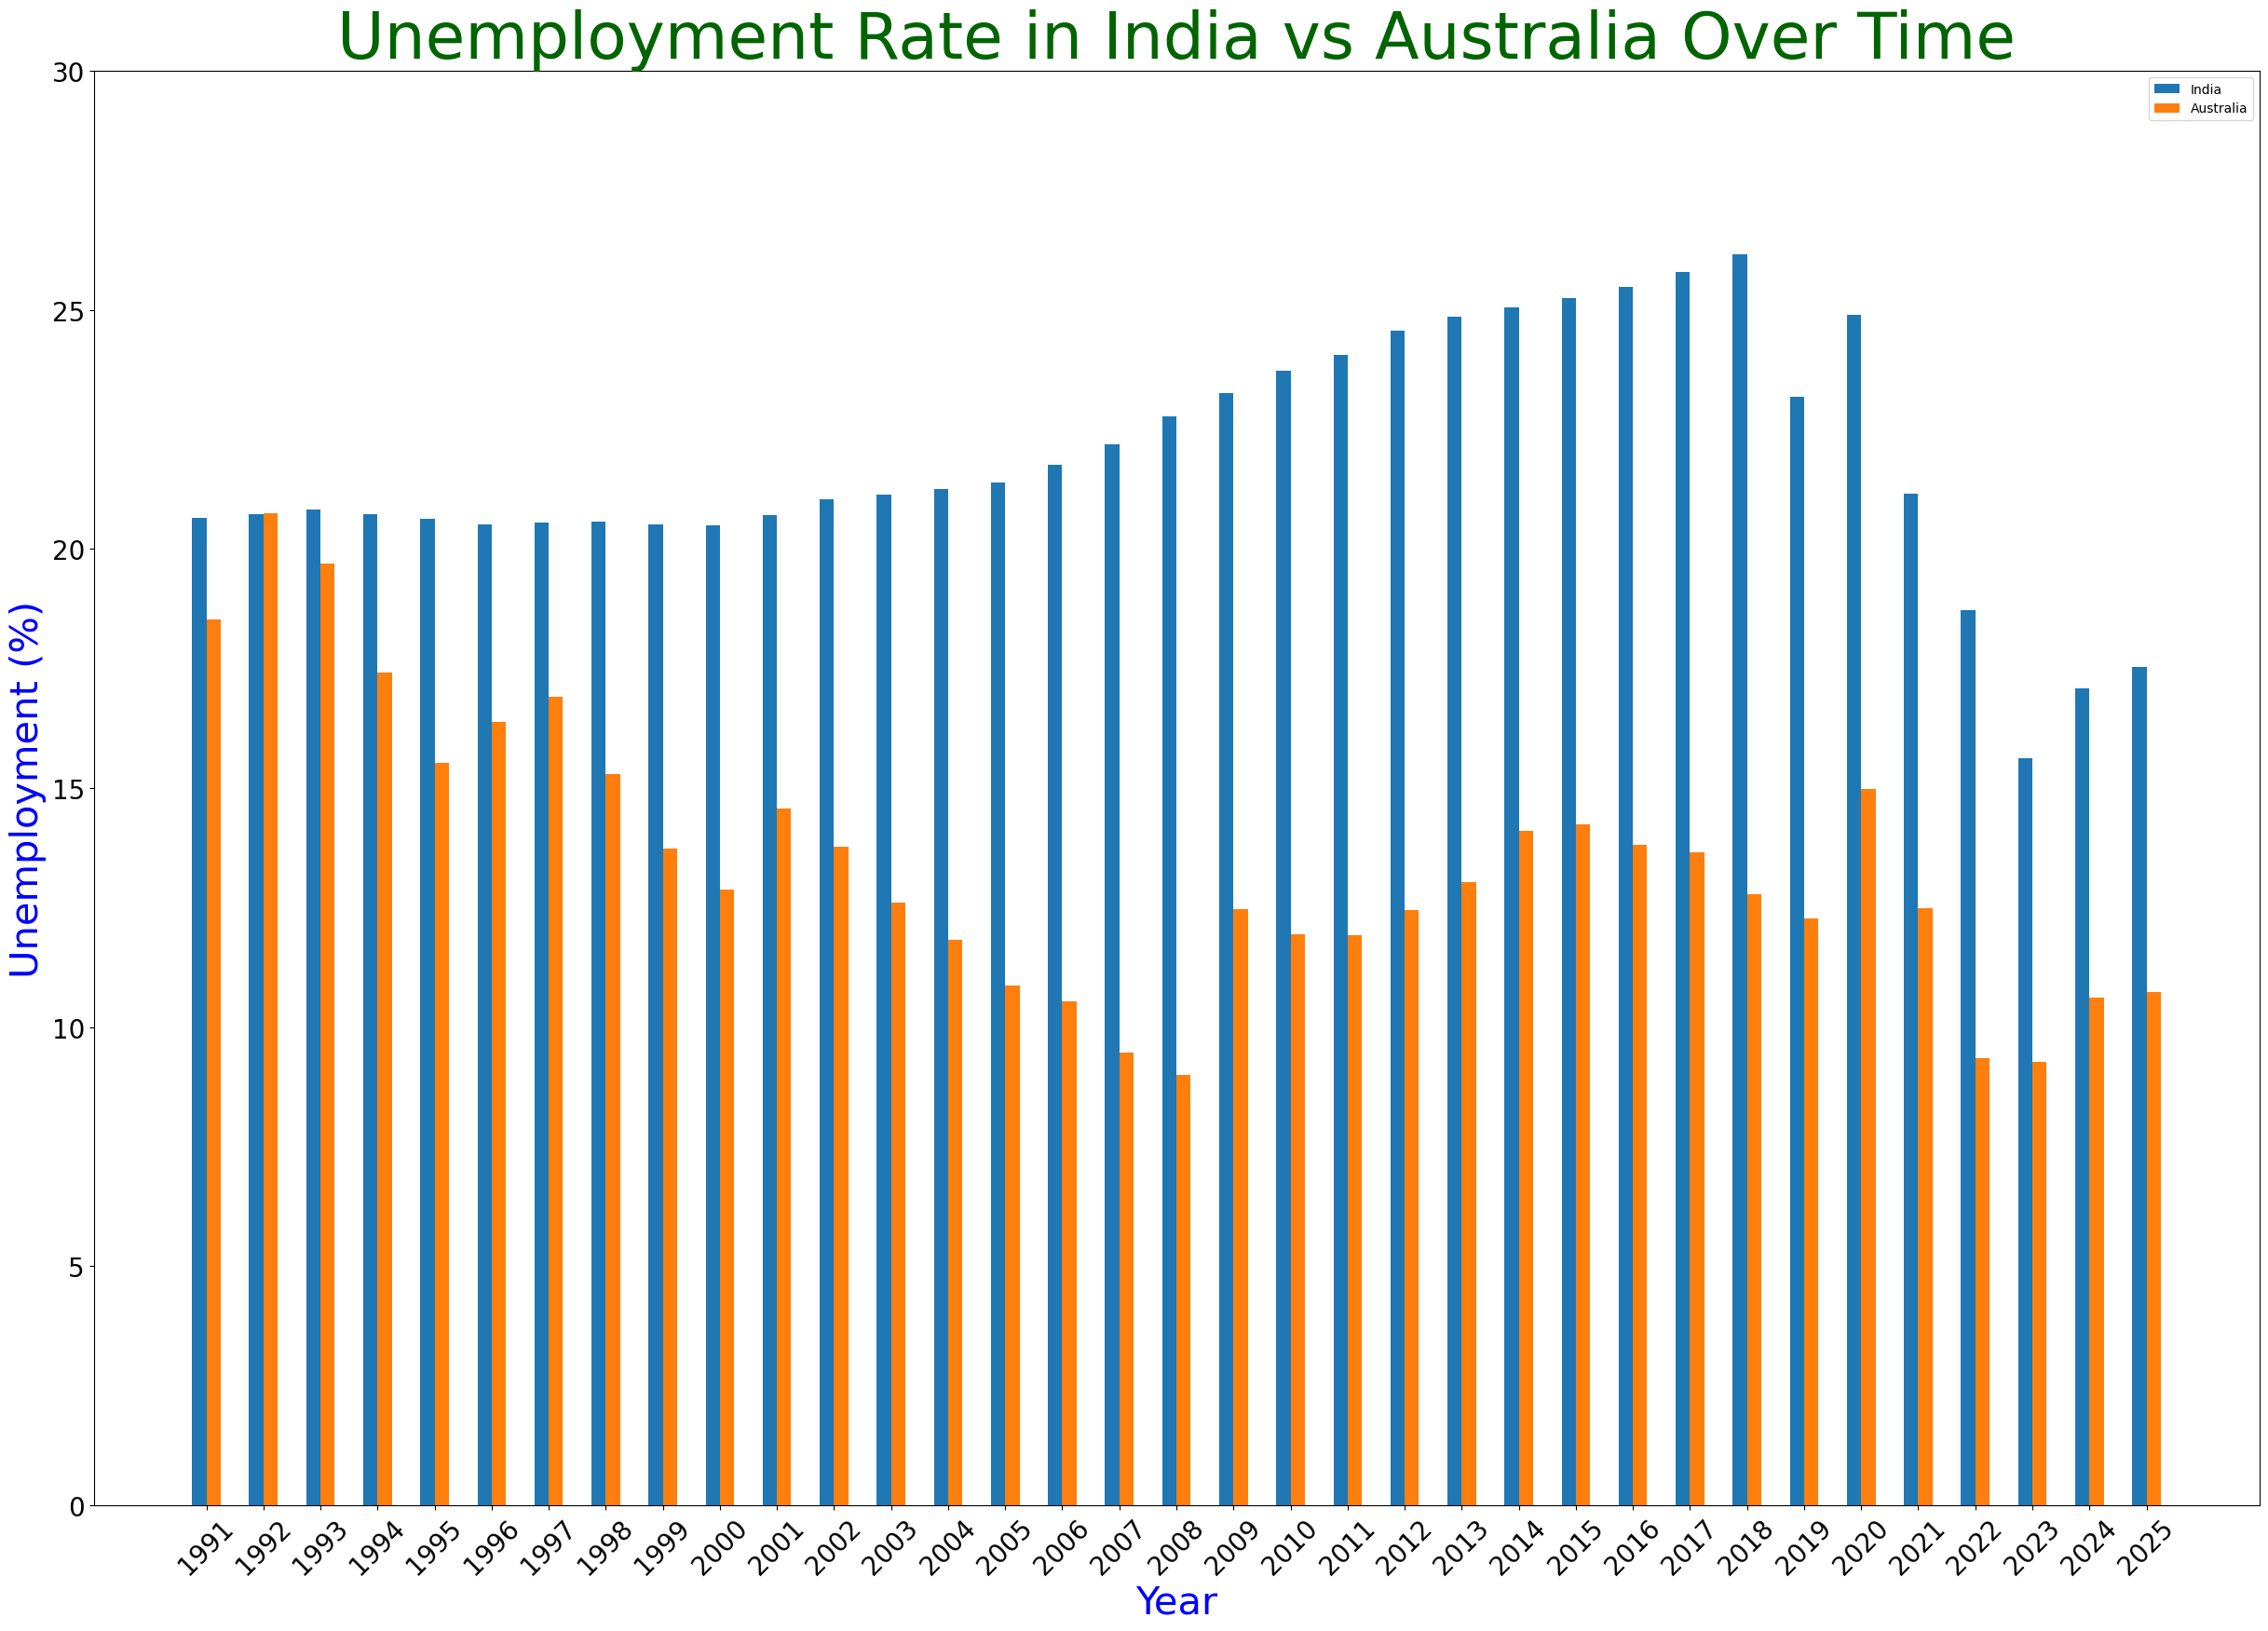

In [32]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(30, 20))

# Filter data Take max obs_value per year for each country
country1_df = df2[df2['country'] == 'India'].groupby('year')['obs_value'].max()
country2_df = df2[df2['country'] == 'Australia'].groupby('year')['obs_value'].max()

# Extract unique years (sorted) values for each yea
years = sorted(df1['year'].unique())
country1 = [country1_df.get(y, np.nan) for y in years]
country2 = [country2_df.get(y, np.nan) for y in years]

# X positions
x = np.arange(len(years))
width = 0.25

# Plot
plt.bar(x - width/2, country1, width, label="India")
plt.bar(x + width/2, country2, width, label="Australia")

# Labels and title
plt.xticks(x, years, fontsize = 20 ,rotation=45)
plt.ylim(0, 30)
plt.yticks(fontsize = 20)
plt.xlabel("Year", fontsize = 30,color="blue")
plt.ylabel("Unemployment (%)",fontsize = 30,color="blue")
plt.title("Unemployment Rate in India vs Australia Over Time",fontsize = 50,color="darkgreen")
plt.legend()

plt.show()


In [28]:
#Testvalues for 1 year disoccupation_zone 
df2_test = pd.read_sql_query("SELECT * FROM disoccupation_zone where country in ('India','Australia') and year = '2025'", conn)
print(df2_test)

   iso_code    country     sex    age  year  obs_value
0       AUS  Australia   Total    15+  2025      4.090
1       AUS  Australia   Total  15-24  2025      9.610
2       AUS  Australia   Total    25+  2025      3.070
3       AUS  Australia    Male    15+  2025      4.128
4       AUS  Australia    Male  15-24  2025     10.727
5       AUS  Australia    Male    25+  2025      2.936
6       AUS  Australia  Female    15+  2025      4.050
7       AUS  Australia  Female  15-24  2025      8.433
8       AUS  Australia  Female    25+  2025      3.219
9       IND      India   Total    15+  2025      4.219
10      IND      India   Total  15-24  2025     16.022
11      IND      India   Total    25+  2025      2.461
12      IND      India    Male    15+  2025      4.249
13      IND      India    Male  15-24  2025     15.541
14      IND      India    Male    25+  2025      2.456
15      IND      India  Female    15+  2025      4.141
16      IND      India  Female  15-24  2025     17.528
17      IN